# Comparison: LGBM vs XGBoost — Quarterly Rolling 3-Year Window (5-Day Gap)

Loads tuned artifacts for both models, re-runs identical quarterly folds with the
**5-day gap** between train_end and test_start applied throughout.

**Metric**: composite = 0.6 × ASA + 0.4 × Macro F1

In [1]:
import sys
import warnings
import pickle
import json
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import f1_score
from IPython.display import display

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path('').resolve()
ROOT = NOTEBOOK_DIR.parents[2]
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments_archive'
for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'ROOT: {ROOT}')

ROOT: /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis


In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import STRIDE_EVAL

df = load_dataset()

def call_decay_from_days(days, halflife=20.0):
    return np.exp(-days.clip(lower=0).fillna(999.0) / halflife)

call_decay = call_decay_from_days(df['days_since_call'])
df['evt_exec_tone']         = df[['transcript_ceo_prep_sentiment_mean_ffill',
                                   'transcript_cfo_prep_sentiment_mean_ffill']].mean(axis=1) * call_decay
df['evt_guidance_topic']     = df['topic_guidance_share_ffill'] * call_decay
df['evt_guidance_sentiment'] = df['topic_guidance_sentiment_ffill'] * call_decay
df['evt_aml_topic']          = df['topic_regulatory_AML_share_ffill'] * call_decay
df['evt_aml_sentiment']      = df['topic_regulatory_AML_sentiment_ffill'] * call_decay

FEATURES = [
    'td_return_5d', 'td_return_20d', 'td_vs_xfn_5d', 'td_dist_52w_high',
    'news_sent_mean_30d', 'news_count_30d', 'days_since_last_news',
    'days_since_call', 'is_earnings_week',
    'evt_exec_tone', 'evt_framing_gap',
    'evt_guidance_topic', 'evt_guidance_sentiment',
    'evt_aml_topic', 'evt_aml_sentiment',
]
TARGET    = 'target_excess_xfn_5d'
THRESHOLD = 0.003
LABEL_MAP = {-1: 0, 0: 1, 1: 2}
INV_MAP   = {0: -1, 1: 0, 2: 1}
STRIDE    = STRIDE_EVAL
GAP_DAYS  = 5   # no-touch buffer: target_excess_xfn_5d uses 5-day forward returns

missing = [f for f in FEATURES if f not in df.columns]
assert not missing, f'Missing: {missing}'
print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Features: {len(FEATURES)}')
print(f'Gap between train_end and test_start: {GAP_DAYS} trading days (target leakage prevention)')

Loaded 1285 rows  |  2021-02-25 to 2026-04-09
Features: 15
Gap between train_end and test_start: 5 trading days (target leakage prevention)


## 1. Load Artifacts

In [3]:
lgb_pkls = sorted(ARTIFACT_DIR.glob('lgbm_quarterly_rolling3y-*.pkl'))
xgb_pkls = sorted(ARTIFACT_DIR.glob('xgb_quarterly_rolling3y-*.pkl'))
assert lgb_pkls, 'No LGBM artifact found'
assert xgb_pkls, 'No XGB artifact found'

with open(lgb_pkls[-1], 'rb') as f: lgb_art = pickle.load(f)
with open(xgb_pkls[-1], 'rb') as f: xgb_art = pickle.load(f)

LGB_PARAMS = lgb_art['best_params']
XGB_PARAMS = xgb_art['best_params']

print(f'LGBM: {lgb_pkls[-1].name}')
print(f'XGB : {xgb_pkls[-1].name}')
print(f'LGBM params: {LGB_PARAMS}')
print(f'XGB  params: {XGB_PARAMS}')
print(f'Gap applied: {lgb_art["gap_days"]} trading days')

LGBM: lgbm_quarterly_rolling3y-2026-04-23.pkl
XGB : xgb_quarterly_rolling3y-2026-04-23.pkl
LGBM params: {'num_leaves': 4, 'min_child_samples': 20, 'n_estimators': 100, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0}
XGB  params: {'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 80, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'tree_method': 'hist'}
Gap applied: 5 trading days


## 2. Define Folds

In [4]:
def make_quarterly_rolling_folds(df, target, train_days=756, min_train_days=504,
                                  quarter_days=63, gap=GAP_DAYS):
    '''
    Rolling-window quarterly folds (3-year / 756 td window).
    gap: trading-day buffer between train_end and test_start to prevent
         label leakage from the 5-day forward return target.
    Rolling window is anchored to train_end (not to test_start) so the
    window size is always exactly train_days.
    '''
    dated = df[df[target].notna()].sort_values('date')
    dates = dated['date'].values
    folds = []
    i, fold_id = min_train_days + gap, 1
    while i < len(dates):
        te_end_i      = min(i + quarter_days - 1, len(dates) - 1)
        train_end_idx = i - 1 - gap                           # last safe training day
        tr_s_i        = max(0, train_end_idx + 1 - train_days) # rolling start
        folds.append((
            fold_id,
            str(dates[tr_s_i])[:10],         # train_start (rolling)
            str(dates[train_end_idx])[:10],  # train_end (gap days before test)
            str(dates[i])[:10],              # test_start
            str(dates[te_end_i])[:10],       # test_end
        ))
        i = te_end_i + 1
        fold_id += 1
    return folds

FOLDS = make_quarterly_rolling_folds(df, TARGET)

print(f'Total quarterly folds: {len(FOLDS)}')
print(f'Rolling window: ~756 trading days (3 years)')
print(f'Gap applied: {GAP_DAYS} trading days between train_end and test_start')
print(f'{"Fold":<6} {"Train start":<13} {"Train end":<13} {"Test start":<13} {"Test end":<13} {"Gap":>5} {"Test rows":>9}')
print('-' * 72)
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    dated_te = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    gap_days = (pd.Timestamp(te_s) - pd.Timestamp(tr_e)).days
    print(f'{fold_id:<6} {tr_s:<13} {tr_e:<13} {te_s:<13} {te_e:<13} {gap_days:>5} {len(dated_te):>9}')

Total quarterly folds: 13
Rolling window: ~756 trading days (3 years)
Gap applied: 5 trading days between train_end and test_start
Fold   Train start   Train end     Test start    Test end        Gap Test rows
------------------------------------------------------------------------
1      2021-02-25    2023-02-28    2023-03-08    2023-06-06        8        63
2      2021-02-25    2023-05-30    2023-06-07    2023-09-06        8        63
3      2021-02-25    2023-08-29    2023-09-07    2023-12-05        9        63
4      2021-02-25    2023-11-28    2023-12-06    2024-03-07        8        63
5      2021-02-25    2024-02-29    2024-03-08    2024-06-06        8        63
6      2021-05-27    2024-05-30    2024-06-07    2024-09-06        8        63
7      2021-08-26    2024-08-29    2024-09-09    2024-12-05       11        63
8      2021-11-25    2024-11-28    2024-12-06    2025-03-10        8        63
9      2022-02-28    2025-03-03    2025-03-11    2025-06-09        8        63
10    

## 3. Run Both Models on All Folds

In [5]:
import lightgbm as lgb

def fit_lgbm(train_df, test_df, params):
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([LABEL_MAP[v] for v in y_tr], dtype=int)
    clf = lgb.LGBMClassifier(objective='multiclass', num_class=3,
                             random_state=42, verbose=-1, n_jobs=1, **params)
    clf.fit(x_tr, y_enc)
    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds     = np.array([INV_MAP[p] for p in clf.predict(x_te)])
    return clf, preds, y_te_cls, y_te_cont

print('fit_lgbm defined.')

fit_lgbm defined.


In [6]:
import xgboost as xgb

def fit_xgb(train_df, test_df, params):
    x_tr  = train_df[FEATURES].fillna(train_df[FEATURES].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([LABEL_MAP[v] for v in y_tr], dtype=int)
    clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3,
                            random_state=42, n_jobs=1, verbosity=0, **params)
    clf.fit(x_tr, y_enc)
    x_te      = test_df[FEATURES].fillna(train_df[FEATURES].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    preds     = np.array([INV_MAP[int(p)] for p in clf.predict(x_te)])
    return clf, preds, y_te_cls, y_te_cont

print('fit_xgb defined.')

fit_xgb defined.


In [7]:
def offset_metrics(preds, y_true_cls, y_true_cont):
    rows = []
    for off in range(STRIDE):
        idx = np.arange(off, len(preds), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows).mean()

print('offset_metrics defined.')

offset_metrics defined.


In [8]:
lgb_rows, xgb_rows = [], []

for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                  (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    if len(test_df) < 5:
        continue

    _, pl, yl, cl = fit_lgbm(train_df, test_df, LGB_PARAMS)
    _, px, yx, cx = fit_xgb(train_df, test_df, XGB_PARAMS)

    ml = offset_metrics(pl, yl, cl)
    mx = offset_metrics(px, yx, cx)

    lgb_rows.append({'fold': fold_id, 'test_start': te_s, 'test_end': te_e, **ml.to_dict()})
    xgb_rows.append({'fold': fold_id, 'test_start': te_s, 'test_end': te_e, **mx.to_dict()})
    print(f'Fold {fold_id:>2}  LGBM asa={ml["active_asa"]:.3f}  XGB asa={mx["active_asa"]:.3f}')

lgb_wf = pd.DataFrame(lgb_rows).set_index('fold')
xgb_wf = pd.DataFrame(xgb_rows).set_index('fold')
print('Done.')

Fold  1  LGBM asa=0.370  XGB asa=0.438


Fold  2  LGBM asa=0.709  XGB asa=0.677


Fold  3  LGBM asa=0.550  XGB asa=0.509


Fold  4  LGBM asa=0.429  XGB asa=0.456


Fold  5  LGBM asa=0.529  XGB asa=0.550


...

Fold  9  LGBM asa=0.605  XGB asa=0.717


Fold 10  LGBM asa=0.619  XGB asa=0.650


Fold 11  LGBM asa=0.526  XGB asa=0.565


Fold 12  LGBM asa=0.499  XGB asa=0.559


Fold 13  LGBM asa=0.450  XGB asa=0.450
Done.


## 4. Per-Fold & Aggregate Comparison

In [9]:
cols = ['mean_acc', 'macro_f1', 'active_cov', 'active_asa']

print('=== Per-Fold — LGBM ===')
display(lgb_wf[cols].round(3))
print('\n=== Per-Fold — XGBoost ===')
display(xgb_wf[cols].round(3))

agg = pd.DataFrame({'LGBM': lgb_wf[cols].mean(), 'XGB': xgb_wf[cols].mean()})
agg['Delta (XGB-LGBM)'] = agg['XGB'] - agg['LGBM']
print('\n=== Aggregate Comparison ===')
display(agg.round(4))

lc = 0.6 * agg.loc['active_asa','LGBM'] + 0.4 * agg.loc['macro_f1','LGBM']
xc = 0.6 * agg.loc['active_asa','XGB']  + 0.4 * agg.loc['macro_f1','XGB']
print(f'\nComposite:  LGBM={lc:.4f}   XGB={xc:.4f}   Delta={xc-lc:+.4f}')
winner = 'LGBM' if lc >= xc else 'XGB'
print(f'Winner on composite: {winner}')

=== Per-Fold — LGBM ===


,mean_acc,macro_f1,active_cov,active_asa
fold,,,,
1,0.271,0.216,0.810,0.370
2,0.540,0.394,0.919,0.709
3,0.381,0.273,0.983,0.550
4,0.336,0.247,1.000,0.429
5,0.428,0.250,0.983,0.529
6,0.509,0.422,0.954,0.681
7,0.462,0.368,0.937,0.512
8,0.410,0.247,0.933,0.468
9,0.573,0.385,1.000,0.605



=== Per-Fold — XGBoost ===


,mean_acc,macro_f1,active_cov,active_asa
fold,,,,
1,0.365,0.293,0.876,0.438
2,0.524,0.389,0.919,0.677
3,0.301,0.182,1.000,0.509
4,0.350,0.250,0.936,0.456
5,0.462,0.306,0.983,0.550
6,0.476,0.434,0.890,0.625
7,0.428,0.343,0.937,0.511
8,0.315,0.207,0.950,0.361
9,0.685,0.469,1.000,0.717



=== Aggregate Comparison ===


,LGBM,XGB,Delta (XGB-LGBM)
mean_acc,0.4137,0.4208,0.0071
macro_f1,0.3031,0.3100,0.0069
active_cov,0.9595,0.9573,-0.0022
active_asa,0.5344,0.5436,0.0092



Composite:  LGBM=0.4419   XGB=0.4501   Delta=+0.0083
Winner on composite: XGB


## 5. Visual Comparison

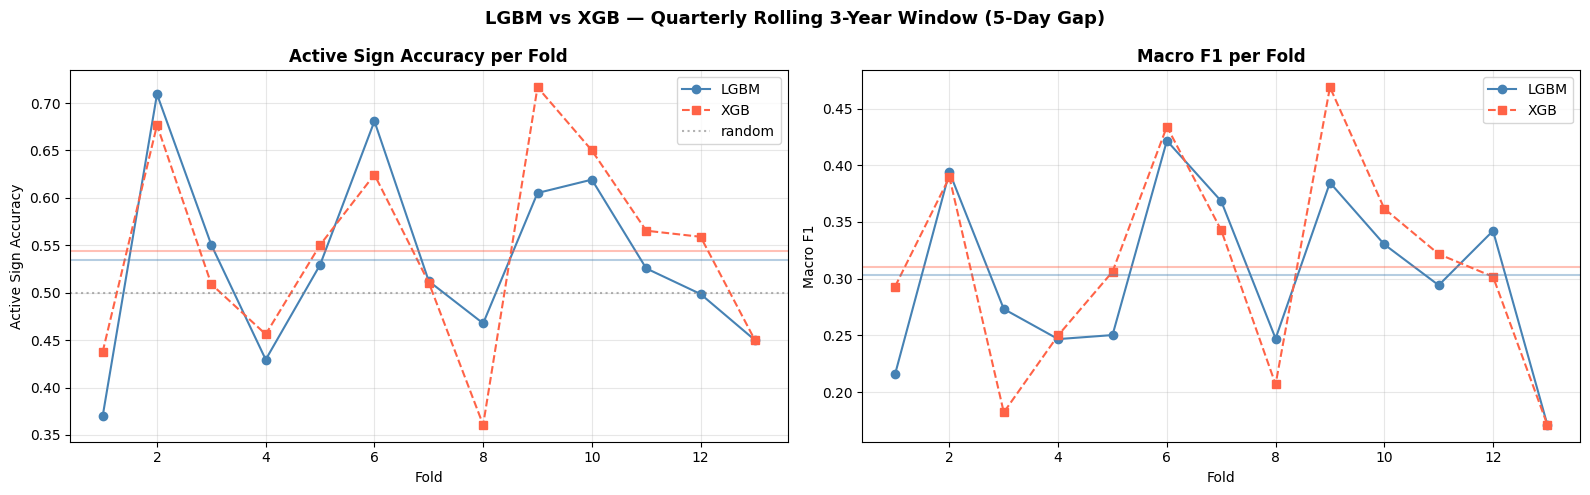

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, ylabel in [
    (axes[0], 'active_asa', 'Active Sign Accuracy'),
    (axes[1], 'macro_f1',   'Macro F1'),
]:
    ax.plot(lgb_wf.index, lgb_wf[metric], marker='o', label='LGBM', color='steelblue')
    ax.plot(xgb_wf.index, xgb_wf[metric], marker='s', label='XGB',  color='tomato', linestyle='--')
    ax.axhline(lgb_wf[metric].mean(), color='steelblue', alpha=0.4, linewidth=1.5)
    ax.axhline(xgb_wf[metric].mean(), color='tomato',    alpha=0.4, linewidth=1.5)
    if metric == 'active_asa':
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6, label='random')
    ax.set_title(f'{ylabel} per Fold', fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('LGBM vs XGB — Quarterly Rolling 3-Year Window (5-Day Gap)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()